In [ ]:
import xgboost as xgb
try:
    # Attempt to create a small dummy matrix on the GPU
    dtrain = xgb.DMatrix([[1.0, 2.0], [3.0, 4.0]], label=[1, 0])
    params = {'tree_method': 'hist', 'device': 'cuda'}
    xgb.train(params, dtrain, num_boost_round=1)
    print("🚀 SUCCESS: XGBoost is talking to your GPU!")
except Exception as e:
    print(f"❌ FAILURE: GPU not accessible. Error: {e}")

🚀 SUCCESS: XGBoost is talking to your GPU!


In [ ]:
# CELL 1: Imports & Setup
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import f1_score, accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

import optuna
from tqdm.notebook import tqdm

optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
N_TRIALS = 50  # Increase to 100-200 for deeper search
DATA_PATH = 'final_processed_data.csv'
os.makedirs("output", exist_ok=True)

print("✓ Libraries imported successfully.")

✓ Libraries imported successfully.


In [ ]:
# CELL 2: Load Data & Define Class Map
df = pd.read_csv(DATA_PATH)

X = df.drop(columns=['target_fertilizer'])
y = df['target_fertilizer'].values

CLASS_MAP = {
    0: 'Balanced NPK Fertilizer',
    1: 'Compost',
    2: 'DAP',
    3: 'General Purpose Fertilizer',
    4: 'Gypsum',
    5: 'Lime',
    6: 'Muriate of Potash',
    7: 'Organic Fertilizer',
    8: 'Urea',
    9: 'Water Retaining Fertilizer',
}

N_CLASSES = len(np.unique(y))
print(f"✓ Dataset loaded: {X.shape[0]} rows, {X.shape[1]} features, {N_CLASSES} classes.")

✓ Dataset loaded: 3100 rows, 44 features, 10 classes.


In [ ]:
# CELL 3: Train/Test Split & Compute Class Weights
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

# Compute balanced sample weights (penalizes misclassification of rare classes)
sample_weights = compute_sample_weight('balanced', y_train)

# Use raw values for tree-based models (scaling not needed)
X_train_arr = X_train.values
X_test_arr = X_test.values

print(f"✓ Split complete. Train: {X_train_arr.shape}, Test: {X_test_arr.shape}")
print("✓ Balanced sample weights computed for imbalanced classes.")

✓ Split complete. Train: (2480, 44), Test: (620, 44)
✓ Balanced sample weights computed for imbalanced classes.


In [ ]:
# CELL 4: Optuna Objective Functions
def cv_macro_f1(model, X, y, sw, cv_folds=5):
    """Manual CV to correctly pass sample_weight to .fit()"""
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for train_idx, val_idx in skf.split(X, y):
        model.fit(X[train_idx], y[train_idx], sample_weight=sw[train_idx])
        preds = model.predict(X[val_idx])
        scores.append(f1_score(y[val_idx], preds, average='macro', zero_division=0))
    return np.mean(scores)

def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 15),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state': RANDOM_STATE,
        'eval_metric': 'mlogloss',
        'n_jobs': 1, # Set to 1 to avoid multiprocessing conflicts during Optuna CV
        'tree_method': 'hist',
        'device': 'cuda',
    }
    model = XGBClassifier(**params)
    return cv_macro_f1(model, X_train_arr, y_train, sample_weights)

def rf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'random_state': RANDOM_STATE,
        'n_jobs': 1
    }
    model = RandomForestClassifier(**params)
    return cv_macro_f1(model, X_train_arr, y_train, sample_weights)

def gb_objective(trial):
    # sklearn's GBM uses max_features instead of colsample_bytree
    # min_samples_leaf acts analogously to min_child_weight
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 200, 1000, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 15),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'random_state': RANDOM_STATE
    }
    model = GradientBoostingClassifier(**params)
    return cv_macro_f1(model, X_train_arr, y_train, sample_weights)

print("✓ Optuna objectives defined.")

✓ Optuna objectives defined.


In [ ]:
# CELL 5: Run Optuna Studies
print("🚀 Starting Hyperparameter Optimization (Maximizing Macro F1)...")

# Create studies
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)

study_rf  = optuna.create_study(direction='maximize', study_name='RF_MacroF1',  sampler=sampler)
study_xgb = optuna.create_study(direction='maximize', study_name='XGB_MacroF1', sampler=sampler)
study_gb  = optuna.create_study(direction='maximize', study_name='GBM_MacroF1', sampler=sampler)

# Run optimizations with progress bars
study_rf.optimize(rf_objective, n_trials=N_TRIALS, show_progress_bar=True)
study_xgb.optimize(xgb_objective, n_trials=N_TRIALS, show_progress_bar=True)
study_gb.optimize(gb_objective, n_trials=N_TRIALS, show_progress_bar=True)

best_params = {
    'RandomForest': study_rf.best_params,
    'XGBoost': study_xgb.best_params,
    'GradientBoosting': study_gb.best_params
}

study_map = {
    'RandomForest': study_rf,
    'XGBoost': study_xgb,
    'GradientBoosting': study_gb
}
for name, params in best_params.items():
    best_val = study_map[name].best_value
    print(f"\n🏆 Best {name} Params (CV Macro F1: {best_val:.4f}):")
    for k, v in params.items():
        print(f"   {k}: {v}")

🚀 Starting Hyperparameter Optimization (Maximizing Macro F1)...


Best trial: 37. Best value: 0.952304: 100%|█████████████████████████████████| 50/50 [1:04:05<00:00, 76.90s/it]


🏆 Best RandomForest Params (CV Macro F1: 0.9541):
   n_estimators: 350
   max_depth: 12
   min_samples_split: 14
   min_samples_leaf: 2
   max_features: None

🏆 Best XGBoost Params (CV Macro F1: 0.9540):
   n_estimators: 900
   learning_rate: 0.16887702500155102
   max_depth: 8
   subsample: 0.8689287168133697
   colsample_bytree: 0.6790892945278517
   min_child_weight: 13
   gamma: 3.818679364822943
   reg_alpha: 0.0020969610721679535
   reg_lambda: 0.0002997755001574116

🏆 Best GradientBoosting Params (CV Macro F1: 0.9523):
   n_estimators: 800
   learning_rate: 0.19584471331424733
   max_depth: 5
   subsample: 0.8186808142041506
   max_features: None
   min_samples_leaf: 10
   min_samples_split: 3


In [ ]:
# CELL 6: Train Final Models with Best Parameters
def get_model(name, params):
    p = params.copy()  # Don't mutate original
    if name == 'RandomForest':
        p['n_jobs'] = -1
        return RandomForestClassifier(**p)
    elif name == 'XGBoost':
        p['n_jobs'] = -1
        p['tree_method'] = 'hist'
        p['device'] = 'cuda'
        return XGBClassifier(**p)
    elif name == 'GradientBoosting':
        return GradientBoostingClassifier(**p)

fitted_models = {}
results = []

for name in ['RandomForest', 'XGBoost', 'GradientBoosting']:
    print(f"\n⏳ Training final {name}...")
    t0 = time.time()

    model = get_model(name, best_params[name])
    model.fit(X_train_arr, y_train, sample_weight=sample_weights)
    elapsed = time.time() - t0

    y_pred = model.predict(X_test_arr)
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'F1_Macro': round(f1_macro, 4),
        'F1_Weighted': round(f1_weighted, 4),
        'Train_Time_s': round(elapsed, 2)
    })
    fitted_models[name] = model

    print(f"✅ {name} | Acc: {acc:.4f} | F1-Macro: {f1_macro:.4f} | Time: {elapsed:.2f}s")

results_df = pd.DataFrame(results).sort_values('F1_Macro', ascending=False).reset_index(drop=True)
print("\n📊 Final Model Comparison:")
print(results_df.to_string(index=False))

# ✅ Save all tuned models for later ensemble or serving
for name, model in fitted_models.items():
    joblib.dump(model, f'output/{name}_optimized.joblib')
    print(f"✓ Saved output/{name}_optimized.joblib")


⏳ Training final RandomForest...
✅ RandomForest | Acc: 0.9452 | F1-Macro: 0.9272 | Time: 0.59s

⏳ Training final XGBoost...
✅ XGBoost | Acc: 0.9306 | F1-Macro: 0.9058 | Time: 1.78s

⏳ Training final GradientBoosting...
✅ GradientBoosting | Acc: 0.9452 | F1-Macro: 0.9324 | Time: 14.95s

📊 Final Model Comparison:
           Model  Accuracy  F1_Macro  F1_Weighted  Train_Time_s
GradientBoosting    0.9452    0.9324       0.9453         14.95
    RandomForest    0.9452    0.9272       0.9454          0.59
         XGBoost    0.9306    0.9058       0.9308          1.78
✓ Saved output/RandomForest_optimized.joblib
✓ Saved output/XGBoost_optimized.joblib
✓ Saved output/GradientBoosting_optimized.joblib


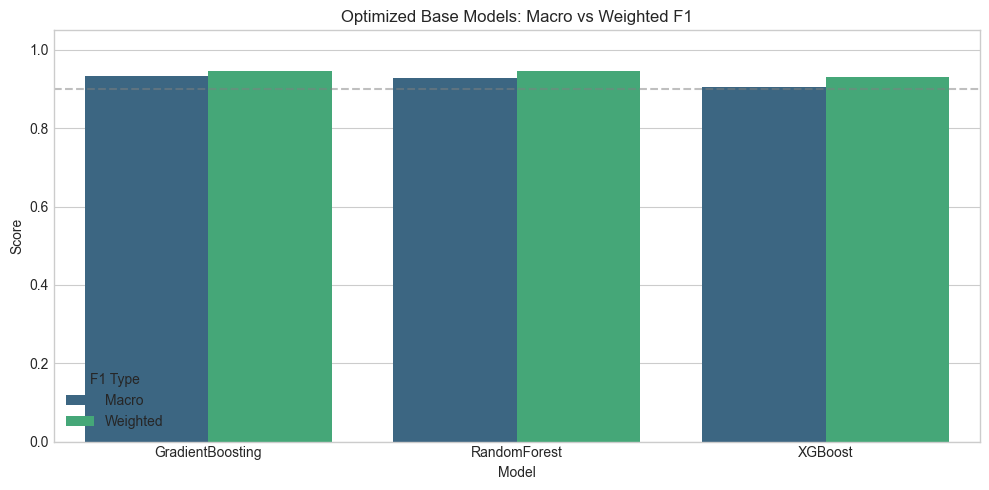

✓ Results saved to output/optimized_model_results.csv & plot saved.


In [ ]:
# CELL 7: Visualize & Save Results
plt.style.use('seaborn-v0_8-whitegrid')

# Bar Chart: Macro vs Weighted F1
plot_df = results_df.melt(id_vars=['Model'], value_vars=['F1_Macro', 'F1_Weighted'],
                          var_name='Metric', value_name='Score')
plot_df['Metric'] = plot_df['Metric'].str.replace('F1_', '')

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x='Model', y='Score', hue='Metric', palette='viridis')
plt.axhline(0.9, color='gray', linestyle='--', alpha=0.5)
plt.ylabel('Score')
plt.title('Optimized Base Models: Macro vs Weighted F1')
plt.ylim(0, 1.05)
plt.legend(title='F1 Type')
plt.tight_layout()
plt.savefig('output/optimized_f1_comparison.png', dpi=150)
plt.show()

results_df.to_csv('output/optimized_model_results.csv', index=False)
print("✓ Results saved to output/optimized_model_results.csv & plot saved.")

PER-CLASS METRICS — Best Model: GradientBoosting
                            precision    recall  f1-score   support

   Balanced NPK Fertilizer       0.84      1.00      0.91        31
                   Compost       0.93      0.88      0.90        75
                       DAP       1.00      0.93      0.97       211
General Purpose Fertilizer       0.75      1.00      0.86         6
                    Gypsum       0.91      0.91      0.91        11
                      Lime       0.95      1.00      0.97        36
         Muriate of Potash       0.95      0.86      0.90        65
        Organic Fertilizer       0.90      1.00      0.95        19
                      Urea       1.00      1.00      1.00        31
Water Retaining Fertilizer       0.91      0.99      0.95       135

                  accuracy                           0.95       620
                 macro avg       0.91      0.96      0.93       620
              weighted avg       0.95      0.95      0.95       6

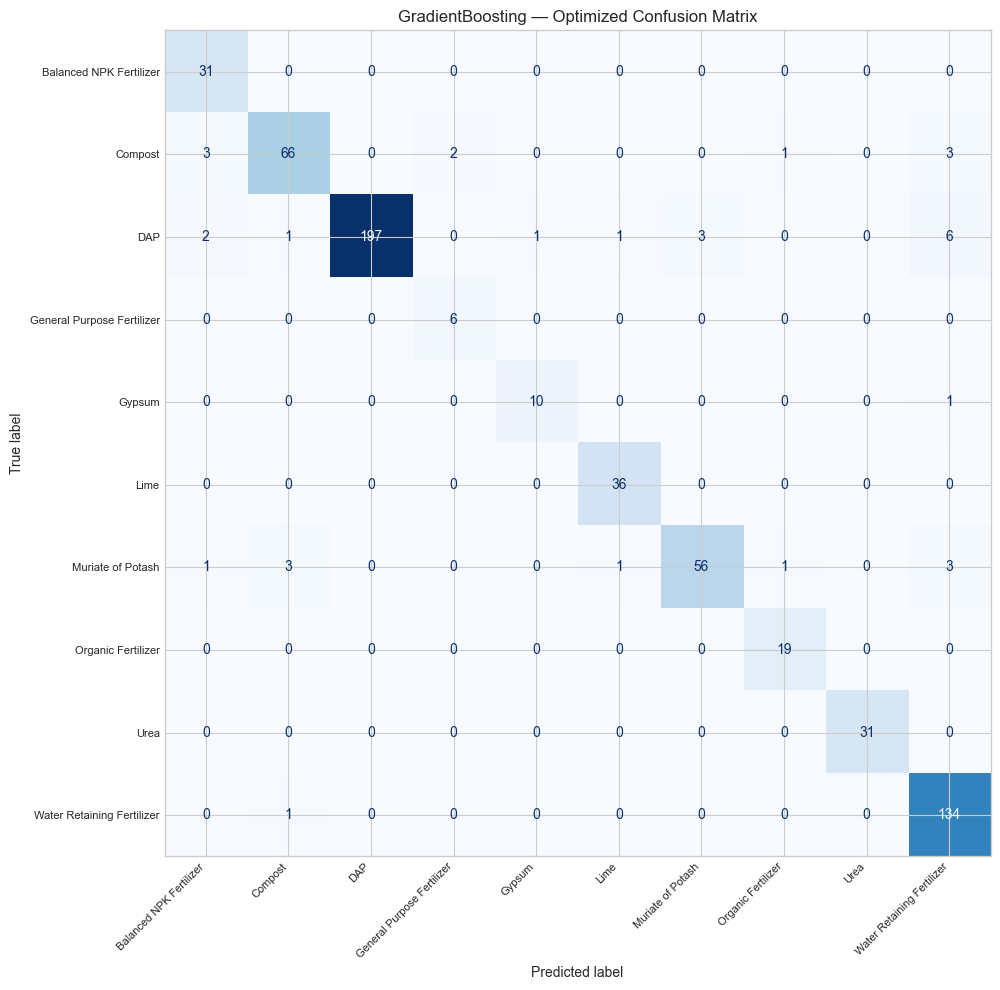

In [ ]:
# CELL 8: Per-Class Performance & Minority Class Diagnostics
from sklearn.metrics import recall_score

best_name = results_df.iloc[0]['Model']
best_model = fitted_models[best_name]

y_pred_best = best_model.predict(X_test_arr)
target_names = [CLASS_MAP[i] for i in range(N_CLASSES)]

print("="*70)
print(f"PER-CLASS METRICS — Best Model: {best_name}")
print("="*70)
print(classification_report(y_test, y_pred_best, target_names=target_names, zero_division=0))

# Minority class warning
print("\n⚠️ Classes with Recall < 0.80 (may need targeted sampling or threshold tuning):")
recalls = pd.Series(recall_score(y_test, y_pred_best, average=None, zero_division=0),
                    index=target_names)
low_recall = recalls[recalls < 0.80]
for cls, rec in low_recall.items():
    CLASS_MAP_INV = {v: k for k, v in CLASS_MAP.items()}
    n_train = np.sum(y_train == CLASS_MAP_INV[cls])
    print(f"   • {cls} | Recall: {rec:.3f} | Train samples: {n_train}")

# Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, ax=ax, colorbar=False,
                                        display_labels=target_names, cmap='Blues')
ax.set_title(f'{best_name} — Optimized Confusion Matrix')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('output/cm_optimized_best.png', dpi=150)
plt.show()

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

shap_values = {}
explainers = {}

for name, model in fitted_models.items():
    print(f"⏳ Computing SHAP for {name}...")

    if name == 'GradientBoosting':
        # Pass predict_proba directly — makes model explicitly callable for shap.Explainer
        # Use a small background sample to keep PermutationExplainer fast
        background = shap.sample(X_test_arr, 100, random_state=RANDOM_STATE)
        explainer = shap.Explainer(model.predict_proba, background,
                                   feature_names=X_test.columns.tolist())
        sv = explainer(X_test_arr)
        shap_values[name] = sv.values  # shape: (n_samples, n_features, n_classes)
    else:
        explainer = shap.TreeExplainer(model)
        sv = explainer.shap_values(X_test_arr)
        shap_values[name] = sv  # list of arrays, one per class

    explainers[name] = explainer
    print(f"✓ SHAP computed for {name}")

⏳ Computing SHAP for RandomForest...
✓ SHAP computed for RandomForest
⏳ Computing SHAP for XGBoost...
✓ SHAP computed for XGBoost
⏳ Computing SHAP for GradientBoosting...


PermutationExplainer explainer: 621it [03:59,  2.53it/s]                                                      

✓ SHAP computed for GradientBoosting


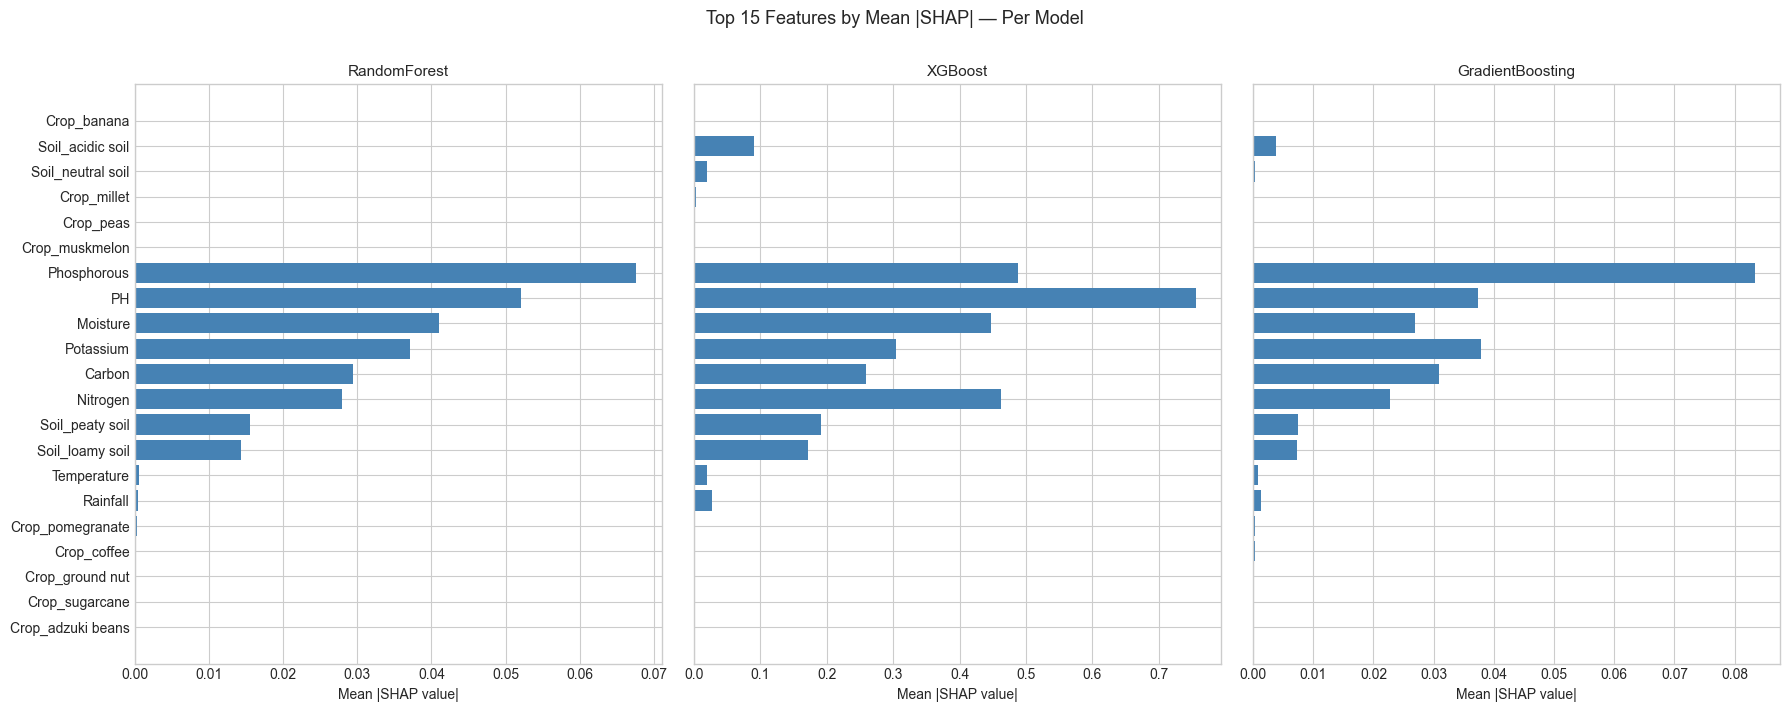

In [ ]:
# --- Plot 1: Mean |SHAP| bar chart per model (side by side) ---
feature_names = X_test.columns.tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 7), sharey=True)

for ax, (name, sv) in zip(axes, shap_values.items()):
    # Normalize shape: GBM returns (n_samples, n_features, n_classes), others return list of (n_samples, n_features)
    if isinstance(sv, list):
        # RF/XGB: list of [n_classes] arrays each (n_samples, n_features)
        mean_abs_shap = np.mean([np.abs(sv[c]).mean(axis=0) for c in range(len(sv))], axis=0)
    elif sv.ndim == 3:
        # GBM via shap.Explainer: (n_samples, n_features, n_classes)
        mean_abs_shap = np.abs(sv).mean(axis=(0, 2))
    else:
        mean_abs_shap = np.abs(sv).mean(axis=0)

    feature_names = X_test.columns.tolist()
    top_idx = np.argsort(mean_abs_shap)[-15:]  # Already int64, but list indexing needs care

    # ✅ Use numpy array indexing instead of list comprehension to avoid the TypeError
    feature_arr = np.array(feature_names)
    ax.barh(feature_arr[top_idx], mean_abs_shap[top_idx], color='steelblue')
    ax.set_title(f'{name}', fontsize=11)
    ax.set_xlabel('Mean |SHAP value|')

plt.suptitle('Top 15 Features by Mean |SHAP| — Per Model', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('output/shap_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

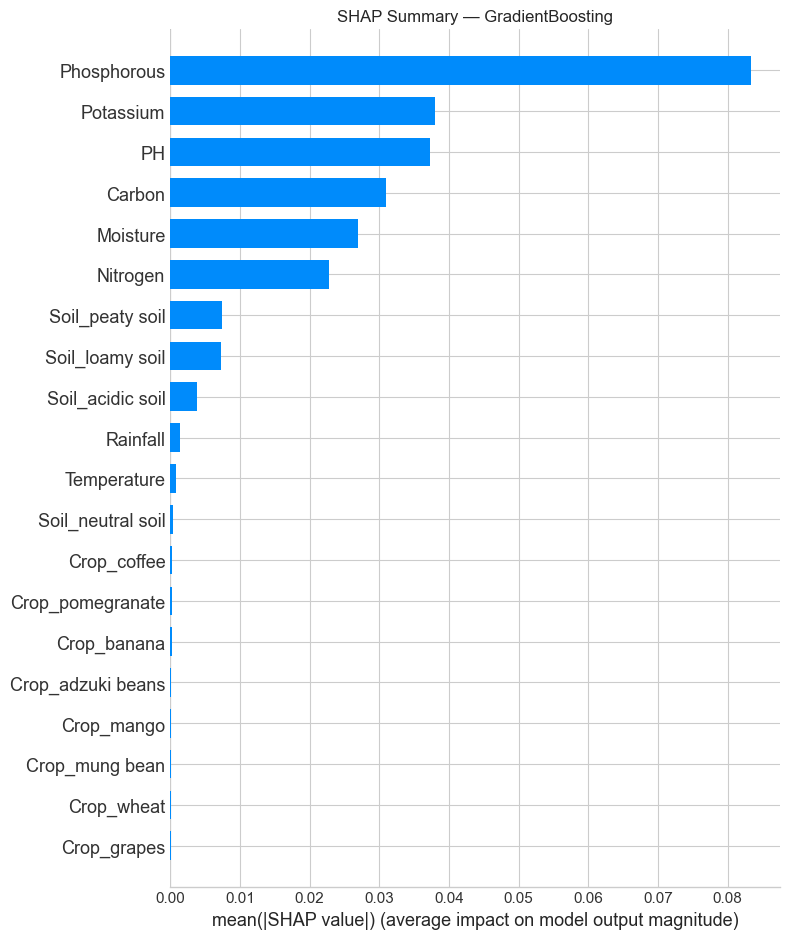

In [ ]:
# --- Plot 2: SHAP beeswarm for best model (shows direction of effect) ---
best_sv = shap_values[best_name]

if isinstance(best_sv, list):
    # RF/XGB: average absolute SHAP across classes
    stacked = np.mean([np.abs(best_sv[c]) for c in range(len(best_sv))], axis=0)
    shap.summary_plot(stacked, X_test, feature_names=X_test.columns.tolist(),
                      plot_type='bar', show=False, max_display=20)
elif best_sv.ndim == 3:
    # GBM: (n_samples, n_features, n_classes) → average across classes
    stacked = np.abs(best_sv).mean(axis=2)
    shap.summary_plot(stacked, X_test, feature_names=X_test.columns.tolist(),
                      plot_type='bar', show=False, max_display=20)
else:
    shap.summary_plot(best_sv, X_test, feature_names=X_test.columns.tolist(),
                      show=False, max_display=20)

plt.title(f'SHAP Summary — {best_name}')
plt.tight_layout()
plt.savefig('output/shap_beeswarm_best.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
from scipy.stats import spearmanr

importance_dict = {}
for name, sv in shap_values.items():
    if isinstance(sv, list):
        # RF / XGB via TreeExplainer: list of (n_samples, n_features), one per class
        importance_dict[name] = np.mean([np.abs(sv[c]).mean(axis=0) for c in range(len(sv))], axis=0)
    elif sv.ndim == 3:
        # GBM via shap.Explainer: (n_samples, n_features, n_classes) → mean over samples AND classes
        importance_dict[name] = np.abs(sv).mean(axis=(0, 2))
    else:
        # Binary / single-output fallback: (n_samples, n_features)
        importance_dict[name] = np.abs(sv).mean(axis=0)

feature_names = X_test.columns.tolist()
importance_df = pd.DataFrame(importance_dict, index=feature_names)

print("📐 Spearman Rank Correlation of Feature Importances:")
model_names = list(fitted_models.keys())
for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        corr, pval = spearmanr(importance_df[model_names[i]], importance_df[model_names[j]])
        print(f"   {model_names[i]} ↔ {model_names[j]}: ρ = {corr:.3f} (p={pval:.3e})")

📐 Spearman Rank Correlation of Feature Importances:
   RandomForest ↔ XGBoost: ρ = 0.542 (p=1.447e-04)
   RandomForest ↔ GradientBoosting: ρ = 0.832 (p=2.715e-12)
   XGBoost ↔ GradientBoosting: ρ = 0.637 (p=3.298e-06)


In [ ]:
# Get all predictions
preds = {name: model.predict(X_test_arr) for name, model in fitted_models.items()}
pred_df = pd.DataFrame(preds)
pred_df['true'] = y_test

# Where do models DISAGREE?
pred_df['all_agree'] = (
    (pred_df['RandomForest'] == pred_df['XGBoost']) &
    (pred_df['XGBoost'] == pred_df['GradientBoosting'])
)
disagreement_rate = (~pred_df['all_agree']).mean()
print(f"\n🔍 Samples where models disagree: {(~pred_df['all_agree']).sum()} / {len(pred_df)} ({disagreement_rate:.1%})")

# Among disagreements — is the true label in ANY model's prediction?
disagreements = pred_df[~pred_df['all_agree']].copy()
disagreements['any_correct'] = disagreements.apply(
    lambda r: r['true'] in [r['RandomForest'], r['XGBoost'], r['GradientBoosting']], axis=1
)
print(f"   → Of those, at least one model was correct: {disagreements['any_correct'].mean():.1%}")
print(f"   → All models wrong simultaneously: {(~disagreements['any_correct']).mean():.1%}")

# Class-level breakdown of disagreements
target_names_series = pd.Series(CLASS_MAP)
print("\n📊 Disagreements by true class:")
print(
    disagreements.groupby('true').size()
    .rename(index=CLASS_MAP)
    .sort_values(ascending=False)
    .to_string()
)


🔍 Samples where models disagree: 12 / 620 (1.9%)
   → Of those, at least one model was correct: 91.7%
   → All models wrong simultaneously: 8.3%

📊 Disagreements by true class:
true
DAP                           7
Muriate of Potash             2
Compost                       1
Gypsum                        1
Water Retaining Fertilizer    1


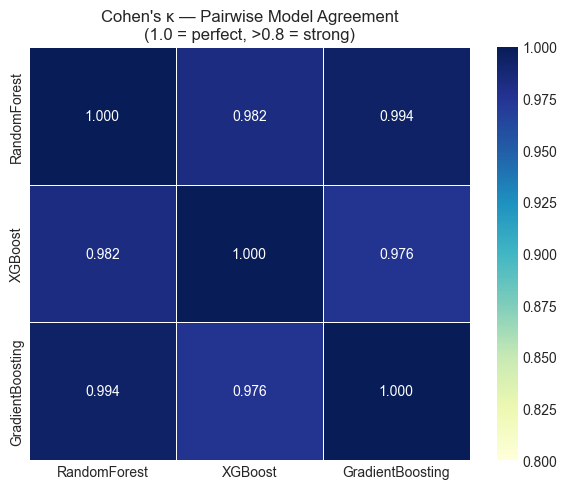

In [ ]:
# Pairwise agreement heatmap
from sklearn.metrics import cohen_kappa_score
import seaborn as sns

models = list(preds.keys())
kappa_matrix = pd.DataFrame(index=models, columns=models, dtype=float)

for m1 in models:
    for m2 in models:
        kappa_matrix.loc[m1, m2] = cohen_kappa_score(preds[m1], preds[m2])

plt.figure(figsize=(6, 5))
sns.heatmap(kappa_matrix.astype(float), annot=True, fmt='.3f', cmap='YlGnBu',
            vmin=0.8, vmax=1.0, linewidths=0.5)
plt.title("Cohen's κ — Pairwise Model Agreement\n(1.0 = perfect, >0.8 = strong)")
plt.tight_layout()
plt.savefig('output/model_agreement_kappa.png', dpi=150)
plt.show()